<a href="https://colab.research.google.com/github/Headtrick/Study-materials/blob/main/Master's_Thesis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import training and validation sets
df = pd.read_csv('/content/drive/MyDrive/TrainAndValid.csv',
                 low_memory=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25628 entries, 0 to 25627
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Moshina modeli  20854 non-null  object 
 1   Pozitsiya       18987 non-null  object 
 2   Kraska          20477 non-null  object 
 3   Rangi           20718 non-null  object 
 4   Yil             20821 non-null  object 
 5   Probeg          20419 non-null  object 
 6   Benzin          0 non-null      float64
 7   Narxi           20610 non-null  object 
 8   Tel             20834 non-null  object 
 9   Location        20469 non-null  object 
dtypes: float64(1), object(9)
memory usage: 2.0+ MB


In [ ]:
df.isna().sum()

,0
Moshina modeli,4774
Pozitsiya,6641
Kraska,5151
Rangi,4910
Yil,4807
Probeg,5209
Benzin,25628
Narxi,5018
Tel,4794
Location,5159


In [ ]:
# Make a copy
df_tmp = df.copy()

In [ ]:
# Check the values of different columns
df_tmp.Location.value_counts()

,count
Location,
Toshkent,9392
Farg'ona,1548
Namangan,1293
Andijon,1255
Samarqand,946
...,...
"Andijon, Shahrixon",1
"Farg'ona, Beshariq tumani",1
Chirchiq shahar,1


In [ ]:
df_tmp.head()

,Moshina modeli,Pozitsiya,Kraska,Rangi,Yil,Probeg,Narxi,Location
0,#Lacetti,1,2,Oq,2012,233000.0,7300,Toshkent viloyati
1,#Cobalt,Avtomat,1,Gk2,2022,130000.0,11000,Andijon
2,#Gentra,3 full,2,Oq,2021,79000.0,12500,Farg'ona
3,#Damas,2,1,Oq,2024,0.0,7900,Buxoro
4,#Cobalt,4 full,1,Oq,2023,43000.0,12200,Navoiy


In [ ]:
pd.api.types.is_string_dtype(df_tmp["Pozitsiya"])

False

In [ ]:
# Find the columns which contain strings
for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        print(label)

Moshina modeli


In [ ]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

Kraska
Yil
Probeg
Narxi


In [ ]:
for label, content in df_tmp.items():
    if pd.api.types.is_datetime64_any_dtype(content):
        print(label)

In [ ]:
# Find columns with mixed data types
for label, content in df_tmp.items():
    if pd.api.types.infer_dtype(content) == 'mixed':
        print(f"{label} contains mixed data types.")

In [ ]:
# Check the inferred data type of each column
for label, content in df_tmp.items():
    print(f"{label}: {pd.api.types.infer_dtype(content)}")

Moshina modeli: string
Pozitsiya: string
Kraska: string
Rangi: string
Yil: string
Probeg: string
Benzin: floating
Narxi: string
Tel: string
Location: string


In [ ]:
# Identify columns containing string-like data
for label, content in df_tmp.items():
    if pd.api.types.infer_dtype(content) in ["string", "mixed", "mixed-integer"]:
        print(label)

Moshina modeli
Pozitsiya
Kraska
Rangi
Yil
Probeg
Narxi
Tel
Location


In [ ]:
# This will turn all of the string value into category values
for label, content in df_tmp.items():
    if pd.api.types.infer_dtype(content) in ["string", "mixed", "mixed-integer"]:
        df_tmp[label] = content.astype('category').cat.as_ordered()

In [ ]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25628 entries, 0 to 25627
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Moshina modeli  20854 non-null  category
 1   Pozitsiya       18987 non-null  category
 2   Kraska          20477 non-null  category
 3   Rangi           20718 non-null  category
 4   Yil             20821 non-null  category
 5   Probeg          20419 non-null  category
 6   Benzin          0 non-null      float64 
 7   Narxi           20610 non-null  category
 8   Tel             20834 non-null  category
 9   Location        20469 non-null  category
dtypes: category(9), float64(1)
memory usage: 1.5 MB


In [ ]:
# Check missing data
df_tmp.isnull().sum()/len(df_tmp)

,0
Moshina modeli,0.186281
Pozitsiya,0.259131
Kraska,0.200991
Rangi,0.191587
Yil,0.187568
Probeg,0.203254
Benzin,1.000000
Narxi,0.195801
Tel,0.187061
Location,0.201303


In [ ]:
# Export current tmp dataframe
df_tmp.to_csv('/content/drive/MyDrive/train_tmp.csv', index=False)

In [ ]:
# Export current tmp dataframe
df_tmp = pd.read_csv('/content/drive/MyDrive/train_tmp.csv', low_memory=False)
df_tmp

,Moshina modeli,Pozitsiya,Kraska,Rangi,Yil,Probeg,Benzin,Narxi,Tel,Location
0,#Lacetti,1,O'ng krilo almashga,Oq,2012,233.000 km,NaN,"7,300$ kelishiladi, faqat naqdga",+998337717175,Toshkent viloyati
1,#Cobalt,Avtomat,"Toza, kapotsa 6sm myatinasi bor",Gk2,2021-2022,130.000 km,NaN,"11,000$",+998940444040,Andijon
2,#Gentra,3 full,Petno 1 qarich,Oq,2021,79.000 km,NaN,"12,500$",+998993630020,Farg'ona
3,#Damas,2,Toza,Oq,2024,Salondan uyga,NaN,"7,900$",+998903405333,Buxoro
4,#Cobalt,4 full,Toza,Oq,2022-2023,43.000 km,NaN,"12,200$",+998935214371,Navoiy
...,...,...,...,...,...,...,...,...,...,...
25623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_tmp.head().T

,0,1,2,3,4
Moshina modeli,#Lacetti,#Cobalt,#Gentra,#Damas,#Cobalt
Pozitsiya,1,Avtomat,3 full,2,4 full
Kraska,O'ng krilo almashga,"Toza, kapotsa 6sm myatinasi bor",Petno 1 qarich,Toza,Toza
Rangi,Oq,Gk2,Oq,Oq,Oq
Yil,2012,2021-2022,2021,2024,2022-2023
Probeg,233.000 km,130.000 km,79.000 km,Salondan uyga,43.000 km
Benzin,NaN,NaN,NaN,NaN,NaN
Narxi,"7,300$ kelishiladi, faqat naqdga","11,000$","12,500$","7,900$","12,200$"
Tel,+998337717175,+998940444040,+998993630020,+998903405333,+998935214371
Location,Toshkent viloyati,Andijon,Farg'ona,Buxoro,Navoiy


In [ ]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

Benzin


In [ ]:
# Check for which numeric columns have null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

Benzin


In [ ]:
df_tmp.head()

,Moshina modeli,Pozitsiya,Kraska,Rangi,Yil,Probeg,Benzin,Narxi,Tel,Location
0,#Lacetti,1,O'ng krilo almashga,Oq,2012,233.000 km,NaN,"7,300$ kelishiladi, faqat naqdga",+998337717175,Toshkent viloyati
1,#Cobalt,Avtomat,"Toza, kapotsa 6sm myatinasi bor",Gk2,2021-2022,130.000 km,NaN,"11,000$",+998940444040,Andijon
2,#Gentra,3 full,Petno 1 qarich,Oq,2021,79.000 km,NaN,"12,500$",+998993630020,Farg'ona
3,#Damas,2,Toza,Oq,2024,Salondan uyga,NaN,"7,900$",+998903405333,Buxoro
4,#Cobalt,4 full,Toza,Oq,2022-2023,43.000 km,NaN,"12,200$",+998935214371,Navoiy


In [ ]:
import re

# Function to clean and convert the 'Narxi' column
def clean_and_convert(value):
    # Remove anything that's not a digit or a decimal point
    cleaned_value = re.sub(r'[^\d.]', '', str(value))
    try:
        # Try to convert the cleaned value to a numeric type (float or int)
        return pd.to_numeric(cleaned_value, errors='coerce')  # Errors will be set to NaN if conversion fails
    except:
        return None  # If it fails to convert, return None

# Assuming df_tmp is already loaded with your data
df_tmp['Narxi'] = df_tmp['Narxi'].apply(clean_and_convert)

# Optionally, fill NaN values with a default value (e.g., 0 or you could leave it as NaN)
df_tmp['Narxi'] = df_tmp['Narxi'].fillna(0)

# Print the cleaned DataFrame
print(df_tmp.head())

# Save the cleaned DataFrame to a CSV file (optional)
df_tmp.to_csv('cleaned_file.csv', index=False)

  Moshina modeli Pozitsiya                           Kraska Rangi        Yil  \
0       #Lacetti         1              O'ng krilo almashga    Oq       2012   
1        #Cobalt   Avtomat  Toza, kapotsa 6sm myatinasi bor   Gk2  2021-2022   
2        #Gentra    3 full                   Petno 1 qarich    Oq       2021   
3         #Damas         2                             Toza    Oq       2024   
4        #Cobalt    4 full                             Toza    Oq  2022-2023   

          Probeg  Benzin    Narxi            Tel           Location  
0     233.000 km     NaN   7300.0  +998337717175  Toshkent viloyati  
1     130.000 km     NaN  11000.0  +998940444040            Andijon  
2      79.000 km     NaN  12500.0  +998993630020           Farg'ona  
3  Salondan uyga     NaN   7900.0  +998903405333             Buxoro  
4      43.000 km     NaN  12200.0  +998935214371             Navoiy  


In [ ]:
df_tmp.head()

,Moshina modeli,Pozitsiya,Kraska,Rangi,Yil,Probeg,Benzin,Narxi,Tel,Location
0,#Lacetti,1,O'ng krilo almashga,Oq,2012,233.0,NaN,7300.0,+998337717175,Toshkent viloyati
1,#Cobalt,Avtomat,"Toza, kapotsa 6sm myatinasi bor",Gk2,2021-2022,130.0,NaN,11000.0,+998940444040,Andijon
2,#Gentra,3 full,Petno 1 qarich,Oq,2021,79.0,NaN,12500.0,+998993630020,Farg'ona
3,#Damas,2,Toza,Oq,2024,0.0,NaN,7900.0,+998903405333,Buxoro
4,#Cobalt,4 full,Toza,Oq,2022-2023,43.0,NaN,12200.0,+998935214371,Navoiy


In [ ]:
df_tmp = pd.read_csv('cleaned_file.csv', low_memory=False)
df_tmp

,Moshina modeli,Pozitsiya,Kraska,Rangi,Yil,Probeg,Benzin,Narxi,Tel,Location
0,#Lacetti,1,O'ng krilo almashga,Oq,2012,233.000 km,NaN,7300.0,+998337717175,Toshkent viloyati
1,#Cobalt,Avtomat,"Toza, kapotsa 6sm myatinasi bor",Gk2,2021-2022,130.000 km,NaN,11000.0,+998940444040,Andijon
2,#Gentra,3 full,Petno 1 qarich,Oq,2021,79.000 km,NaN,12500.0,+998993630020,Farg'ona
3,#Damas,2,Toza,Oq,2024,Salondan uyga,NaN,7900.0,+998903405333,Buxoro
4,#Cobalt,4 full,Toza,Oq,2022-2023,43.000 km,NaN,12200.0,+998935214371,Navoiy
...,...,...,...,...,...,...,...,...,...,...
25623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
25624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
25625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
25626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [ ]:
# Function to clean and convert the 'Probeg' column
def clean_and_convert_probeg(value):
    # Remove anything that's not a digit
    cleaned_value = re.sub(r'[^\d]', '', str(value))  # Remove non-numeric characters (including ".")
    try:
        # Convert to numeric (int)
        return pd.to_numeric(cleaned_value, errors='coerce')
    except:
        return None  # Return None if conversion fails

# Assuming df_tmp is already loaded with your data
df_tmp['Probeg'] = df_tmp['Probeg'].apply(clean_and_convert_probeg)

# Optionally, fill NaN values with a default value (e.g., 0 or you could leave it as NaN)
df_tmp['Probeg'] = df_tmp['Probeg'].fillna(0)

# Print the cleaned DataFrame
print(df_tmp.head())

# Save the cleaned DataFrame to a CSV file (optional)
df_tmp.to_csv('cleaned_file_with_probeg.csv', index=False)

  Moshina modeli Pozitsiya                           Kraska Rangi        Yil  \
0       #Lacetti         1              O'ng krilo almashga    Oq       2012   
1        #Cobalt   Avtomat  Toza, kapotsa 6sm myatinasi bor   Gk2  2021-2022   
2        #Gentra    3 full                   Petno 1 qarich    Oq       2021   
3         #Damas         2                             Toza    Oq       2024   
4        #Cobalt    4 full                             Toza    Oq  2022-2023   

     Probeg  Benzin    Narxi            Tel           Location  
0  233000.0     NaN   7300.0  +998337717175  Toshkent viloyati  
1  130000.0     NaN  11000.0  +998940444040            Andijon  
2   79000.0     NaN  12500.0  +998993630020           Farg'ona  
3       0.0     NaN   7900.0  +998903405333             Buxoro  
4   43000.0     NaN  12200.0  +998935214371             Navoiy  


In [ ]:
df_tmp = df_tmp.drop(columns=['Tel'])
df_tmp

,Moshina modeli,Pozitsiya,Kraska,Rangi,Yil,Probeg,Benzin,Narxi,Location
0,#Lacetti,1,O'ng krilo almashga,Oq,2012,233000.0,NaN,7300.0,Toshkent viloyati
1,#Cobalt,Avtomat,"Toza, kapotsa 6sm myatinasi bor",Gk2,2021-2022,130000.0,NaN,11000.0,Andijon
2,#Gentra,3 full,Petno 1 qarich,Oq,2021,79000.0,NaN,12500.0,Farg'ona
3,#Damas,2,Toza,Oq,2024,0.0,NaN,7900.0,Buxoro
4,#Cobalt,4 full,Toza,Oq,2022-2023,43000.0,NaN,12200.0,Navoiy
...,...,...,...,...,...,...,...,...,...
25623,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
25624,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
25625,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
25626,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [ ]:
df_tmp = df_tmp.drop(columns=['Benzin'])
df_tmp

,Moshina modeli,Pozitsiya,Kraska,Rangi,Yil,Probeg,Narxi,Location
0,#Lacetti,1,O'ng krilo almashga,Oq,2012,233000.0,7300.0,Toshkent viloyati
1,#Cobalt,Avtomat,"Toza, kapotsa 6sm myatinasi bor",Gk2,2021-2022,130000.0,11000.0,Andijon
2,#Gentra,3 full,Petno 1 qarich,Oq,2021,79000.0,12500.0,Farg'ona
3,#Damas,2,Toza,Oq,2024,0.0,7900.0,Buxoro
4,#Cobalt,4 full,Toza,Oq,2022-2023,43000.0,12200.0,Navoiy
...,...,...,...,...,...,...,...,...
25623,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
25624,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
25625,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
25626,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN


In [ ]:
# Function to clean and convert the 'Yil' column
def clean_and_convert_year(value):
    # Check if the value contains a range (e.g., "2021-2022")
    if isinstance(value, str) and '-' in value:
        # Extract the second year in the range
        years = value.split('-')
        if len(years) > 1:
            # Clean both years and return the second one
            cleaned_year = re.sub(r'\D', '', years[1])  # Remove non-numeric characters from the second year
            # Check if cleaned_year is not empty before converting to int
            if cleaned_year:
                return int(cleaned_year)
    # Otherwise, clean and convert the year (remove non-numeric characters)
    cleaned_value = re.sub(r'\D', '', str(value))  # Remove non-numeric characters
    if cleaned_value:  # If there's any valid year part after cleaning
        return int(cleaned_value)
    return None  # Return None if no valid year is found

# Assuming df_tmp is already loaded with your data

# Clean the 'Yil' column by applying the function
df_tmp['Yil'] = df_tmp['Yil'].apply(clean_and_convert_year)

# Fill NaN values in 'Yil' with a default year, e.g., 0 or the mean year (or handle based on your needs)
df_tmp['Yil'] = df_tmp['Yil'].fillna(0).astype(int)

# Print the cleaned DataFrame
print(df_tmp.head())

# Save the cleaned DataFrame to a CSV file (optional)
df_tmp.to_csv('cleaned_file_without_tel_and_corrected_year.csv', index=False)

  Moshina modeli Pozitsiya                           Kraska Rangi   Yil  \
0       #Lacetti         1              O'ng krilo almashga    Oq  2012   
1        #Cobalt   Avtomat  Toza, kapotsa 6sm myatinasi bor   Gk2  2022   
2        #Gentra    3 full                   Petno 1 qarich    Oq  2021   
3         #Damas         2                             Toza    Oq  2024   
4        #Cobalt    4 full                             Toza    Oq  2023   

     Probeg    Narxi           Location  
0  233000.0   7300.0  Toshkent viloyati  
1  130000.0  11000.0            Andijon  
2   79000.0  12500.0           Farg'ona  
3       0.0   7900.0             Buxoro  
4   43000.0  12200.0             Navoiy  


In [ ]:
df_tmp.isna().sum()

,0
Moshina modeli,4774
Pozitsiya,6641
Kraska,5151
Rangi,4910
Yil,0
Probeg,0
Narxi,0
Location,5159


In [ ]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25628 entries, 0 to 25627
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Moshina modeli  20854 non-null  object 
 1   Pozitsiya       18987 non-null  object 
 2   Kraska          20477 non-null  object 
 3   Rangi           20718 non-null  object 
 4   Yil             25628 non-null  int64  
 5   Probeg          25628 non-null  float64
 6   Narxi           25628 non-null  float64
 7   Location        20469 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 1.6+ MB


In [ ]:
df_tmp.to_csv('/content/drive/MyDrive/Final_cleaned.csv', index=False)

In [ ]:
df_tmp = pd.read_csv('/content/drive/MyDrive/Final_Project.csv', low_memory=False)
df_tmp

,Moshina modeli,Pozitsiya,Kraska,Rangi,Yil,Probeg,Narxi,Location
0,#Lacetti,1,2,Oq,2012,233000.0,7300,Toshkent viloyati
1,#Cobalt,Avtomat,1,Gk2,2022,130000.0,11000,Andijon
2,#Gentra,3 full,2,Oq,2021,79000.0,12500,Farg'ona
3,#Damas,2,1,Oq,2024,0.0,7900,Buxoro
4,#Cobalt,4 full,1,Oq,2023,43000.0,12200,Navoiy
...,...,...,...,...,...,...,...,...
19416,#Nexia 3,Full,1,Oq,2021,23000.0,3000,Toshkentga beriladi
19417,#Tracker,Full,1,Qora,2021,18000.0,10000,Toshkentga beriladi
19418,#Epica,3,1,Qora,20102012,251000.0,8500,Toshkent
19419,#Spark,4,2,Oq,2019,47000.0,9500,Toshkent


In [ ]:
# Rename the 'Location' column
df_tmp = df_tmp.rename(columns={'Location': 'Lokatsiya'})

In [ ]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

Kraska
Yil
Probeg
Narxi


In [ ]:
df_tmp.Yil

,Yil
0,2012
1,2022
2,2021
3,2024
4,2023
...,...
19416,2021
19417,2021
19418,20102012
19419,2019


In [ ]:
# Check for which numeric columns have null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

In [ ]:
# Remove rows with NaN values in the 'Moshina modeli' column
df_tmp_cleaned = df_tmp.dropna(subset=['Moshina modeli'])

# Print the cleaned DataFrame
print(df_tmp_cleaned.head())

# Optionally, save the cleaned DataFrame to a CSV file
df_tmp_cleaned.to_csv('cleaned_file_without_nan_modeli.csv', index=False)

  Moshina modeli Pozitsiya                           Kraska Rangi   Yil  \
0       #Lacetti         1              O'ng krilo almashga    Oq  2012   
1        #Cobalt   Avtomat  Toza, kapotsa 6sm myatinasi bor   Gk2  2022   
2        #Gentra    3 full                   Petno 1 qarich    Oq  2021   
3         #Damas         2                             Toza    Oq  2024   
4        #Cobalt    4 full                             Toza    Oq  2023   

     Probeg    Narxi           Location  
0  233000.0   7300.0  Toshkent viloyati  
1  130000.0  11000.0            Andijon  
2   79000.0  12500.0           Farg'ona  
3       0.0   7900.0             Buxoro  
4   43000.0  12200.0             Navoiy  


In [ ]:
df_tmp_cleaned

,Moshina modeli,Pozitsiya,Kraska,Rangi,Yil,Probeg,Narxi,Location
0,#Lacetti,1,O'ng krilo almashga,Oq,2012,233000.0,7300.0,Toshkent viloyati
1,#Cobalt,Avtomat,"Toza, kapotsa 6sm myatinasi bor",Gk2,2022,130000.0,11000.0,Andijon
2,#Gentra,3 full,Petno 1 qarich,Oq,2021,79000.0,12500.0,Farg'ona
3,#Damas,2,Toza,Oq,2024,0.0,7900.0,Buxoro
4,#Cobalt,4 full,Toza,Oq,2023,43000.0,12200.0,Navoiy
...,...,...,...,...,...,...,...,...
25607,#Nexia 3,Full,Toza,Oq,2021,23000.0,3000.0,Toshkentga beriladi
25608,#Tracker,Full,Toza,Qora,2021,18000.0,10000.0,Toshkentga beriladi
25617,#Epica,3,Toza,Qora,20102012,251000.0,8500.0,Toshkent
25618,#Spark,4,2 ta detalda petno bor,Oq,2019,47000.0,9500.0,Toshkent


In [ ]:
df_tmp.isna().sum()

,0
Moshina modeli,0
Pozitsiya,0
Kraska,0
Rangi,0
Yil,0
Probeg,0
Narxi,0
Location,0


In [ ]:
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)

Moshina modeli
Pozitsiya
Rangi
Location


In [ ]:
# Turn categorical variables into numbers and fill missing
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        # Add binary column to indicate whether sample had missing value
        df_tmp[label+'_is_missing'] = pd.isnull(content)
        # Turn categories into numbers and add +1
        df_tmp[label] = pd.Categorical(content).codes + 1

In [ ]:
# prompt: Since we turned string into categories I need to map string into csv file to check what number represent what string please provide mapping code

import pandas as pd

# Load your dataframe (replace 'your_file.csv' with the actual file path)
df_tmp = pd.read_csv('/content/drive/MyDrive/Final_cleaned.csv', low_memory=False)

# Create a dictionary to store the mappings
mappings = {}

# Iterate through non-numeric columns
for col in df_tmp.columns:
    if not pd.api.types.is_numeric_dtype(df_tmp[col]):
        # Get the unique categories and their codes
        categories = df_tmp[col].unique()
        codes = pd.Categorical(df_tmp[col]).codes

        # Store the mapping in the dictionary
        mappings[col] = dict(zip(categories, codes + 1))  # +1 because codes start at 0

# Print the mappings or save to a file
for col, mapping in mappings.items():
    print(f"Mapping for column '{col}':")
    print(mapping)
    print("---")

# Example of how to save the mappings to a CSV file:
import csv
with open('category_mappings.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Column', 'Category', 'Code'])
    for col, mapping in mappings.items():
        for category, code in mapping.items():
            writer.writerow([col, category, code])

Mapping for column 'Moshina modeli':
{'#Lacetti': 528, '#Cobalt': 191, '#Gentra': 296, '#Damas': 214, '#Labo': 191, '#Malibu': 503, '#Depal s7': 191, '#Jiguli 06': 214, '#Spark': 653, '#Nexia 2': 227, '#Tracker 2': 444, '#Hyundai Grand  Starex': 856, '#Hyundai Elantra': 296, '#Lacetti 1.8L': 191, '#Onix': 191, '#Byd Champion': 296, '#Orlando': 214, '#Hyundai Creta': 191, '#Nexia 3': 759, '#Malibu 1': 856, '#Kia': 904, '#Volga 3102': 350, '#Epica': 856, '#BYD Champion Full': 191, '#Tracker': 759, '#Volkswagen E Lavida': 347, 'Patriot': 540, '#Nissan Sunny': 856, '#Tico': 810, '#Kia Seltos': 296, '#Kia K5': 296, '#Monza': 103, '#Volga 31105': 296, '#Matiz Best': 296, '#Isuzu D Max 2.5': 820, '#Matiz best': 856, '#Hyundai Tucson': 345, '#Mercedes Benz Vito': 775, '#Malibu 2': 296, '#Captiva 4': 654, '#Matiz': 468, '#Captiva 3': 965, '#Mercedes Benz vito pasajirniy': 965, '#Captiva 2': 238, '#Byd E2': 191, '#Lada vesta cw cross': 214, '#Captiva 2.4': 35, '#Lada samara 09': 191, '#Shineray 

In [ ]:
from google.colab import files
files.download('category_mappings.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# prompt: download category_mappings.csv

import pandas as pd

# Assuming 'category_mappings.csv' is in the current working directory
try:
    mappings_df = pd.read_csv('category_mappings.csv')
    print(mappings_df)
except FileNotFoundError:
    print("Error: 'category_mappings.csv' not found in the current directory.")

              Column                             Category  Code
0     Moshina modeli                             #Lacetti   528
1     Moshina modeli                              #Cobalt   191
2     Moshina modeli                              #Gentra   296
3     Moshina modeli                               #Damas   214
4     Moshina modeli                                #Labo   191
...              ...                                  ...   ...
4701        Location            Faqat Toshkentga beriladi   134
4702        Location  Surxondaryo viloyati, Termiz shahri     3
4703        Location                Toshkent, Surxondaryo   202
4704        Location                              Oltariq   202
4705        Location   Nasiya Savdoga Toshkentga beriladi   202

[4706 rows x 3 columns]


In [ ]:
pd.Categorical(df_tmp["Location"]).codes

array([248,   2,  47, ..., 201, 201, 201], dtype=int16)

In [ ]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19421 entries, 0 to 19420
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Moshina modeli             19421 non-null  int16  
 1   Pozitsiya                  19421 non-null  int16  
 2   Kraska                     19421 non-null  int64  
 3   Rangi                      19421 non-null  int16  
 4   Yil                        19421 non-null  int64  
 5   Probeg                     19421 non-null  float64
 6   Narxi                      19421 non-null  int64  
 7   Lokatsiya                  19421 non-null  int16  
 8   Moshina modeli_is_missing  19421 non-null  bool   
 9   Pozitsiya_is_missing       19421 non-null  bool   
 10  Rangi_is_missing           19421 non-null  bool   
 11  Lokatsiya_is_missing       19421 non-null  bool   
dtypes: bool(4), float64(1), int16(4), int64(3)
memory usage: 834.6 KB


In [ ]:
df_tmp.head().T

,0,1,2,3,4
Moshina modeli,528.0,191.0,296.0,214.0,191.0
Pozitsiya,4.0,1721.0,1106.0,398.0,1552.0
Kraska,2.0,1.0,2.0,1.0,1.0
Rangi,302.0,129.0,302.0,302.0,302.0
Yil,2012.0,2022.0,2021.0,2024.0,2023.0
Probeg,233000.0,130000.0,79000.0,0.0,43000.0
Narxi,7300.0,11000.0,12500.0,7900.0,12200.0
Lokatsiya,249.0,3.0,48.0,30.0,108.0


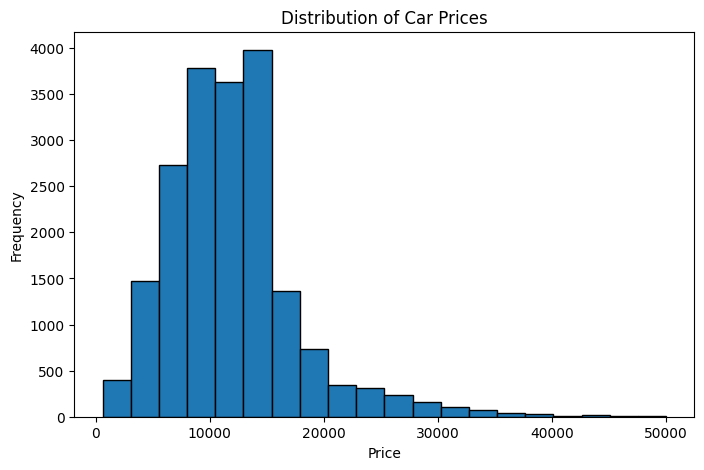

In [ ]:
# @title Distribution of Car Prices

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_tmp['Narxi'], bins=20, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
_ = plt.title('Distribution of Car Prices')

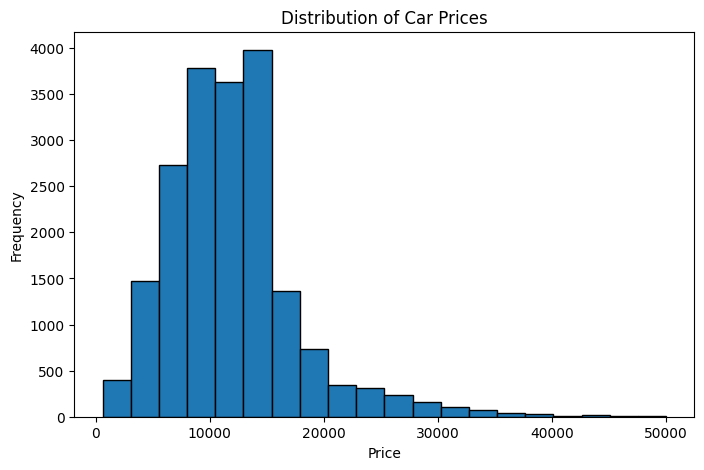

In [ ]:
# @title Distribution of Car Prices

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_tmp['Narxi'], bins=20, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
_ = plt.title('Distribution of Car Prices')

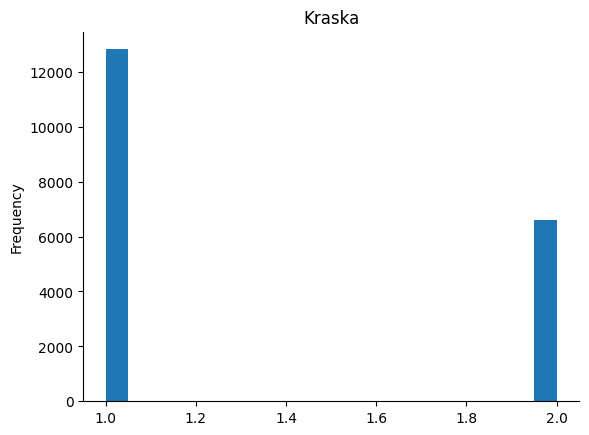

In [ ]:
# @title Kraska

from matplotlib import pyplot as plt
df_tmp['Kraska'].plot(kind='hist', bins=20, title='Kraska')
plt.gca().spines[['top', 'right',]].set_visible(False)

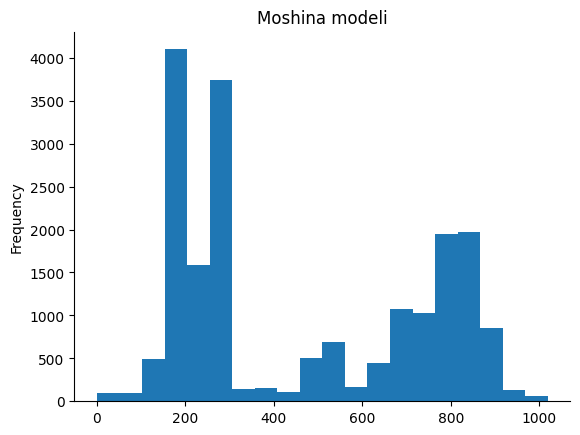

In [ ]:
# @title Moshina modeli

from matplotlib import pyplot as plt
df_tmp['Moshina modeli'].plot(kind='hist', bins=20, title='Moshina modeli')
plt.gca().spines[['top', 'right',]].set_visible(False)

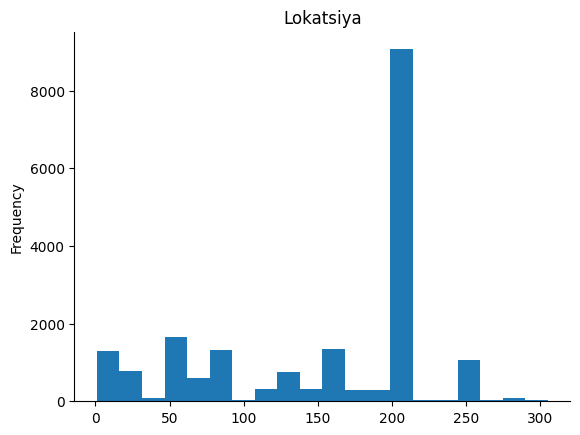

In [ ]:
# @title Moshina modeli

from matplotlib import pyplot as plt
df_tmp['Lokatsiya'].plot(kind='hist', bins=20, title='Lokatsiya')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df_tmp.isna().sum()

,0
Moshina modeli,0
Pozitsiya,0
Kraska,0
Rangi,0
Yil,0
Probeg,0
Narxi,0
Lokatsiya,0


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% for training and 20% for testing
df_train, df_test = train_test_split(df_tmp, test_size=0.2, random_state=42)

# Save the training dataset as a new CSV file
df_train.to_csv('main_data.csv', index=False)

# Save the testing dataset as a new CSV file
df_test.to_csv('test_data.csv', index=False)

print("Dataset split and saved as 'main_data.csv' and 'test_data.csv'.")

Dataset split and saved as 'main_data.csv' and 'test_data.csv'.


In [ ]:
from google.colab import files
files.download('test_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import time

In [ ]:
import time
from sklearn.ensemble import RandomForestRegressor

# Start the timer
start_time = time.time()

# Instantiate and fit the model
model = RandomForestRegressor(n_jobs=-1, random_state=42)
model.fit(df_tmp.drop('Narxi', axis=1), df_tmp['Narxi'])

# End the timer and print the elapsed time
elapsed_time = time.time() - start_time
print(f"Execution time: {elapsed_time:.2f} seconds")

Execution time: 7.25 seconds


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming df_tmp is your dataset
# Randomly split data into 80% training and 20% validation set
df_train, df_val = train_test_split(df_tmp, test_size=0.2, random_state=42)

# Check the size of the splits
len(df_train), len(df_val)

(15536, 3885)

In [ ]:
# Split data into X & y
X_train, y_train = df_train.drop('Narxi', axis=1), df_train.Narxi
X_valid, y_valid = df_val.drop("Narxi", axis=1), df_val.Narxi

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((15536, 11), (15536,), (3885, 11), (3885,))

In [ ]:
y_train

,Narxi
5350,11700
8380,13200
11509,3200
6699,8150
3002,14000
...,...
11284,17200
11964,14200
5390,12600
860,1900


In [ ]:
# Create evaluation function (the competition uses RMSLE)
from sklearn.metrics import mean_squared_log_error, mean_absolute_error
from sklearn.metrics import r2_score

def rmsle(y_test, y_preds):
    '''
    Calculates root mean squared log error between predictions and
    true labels.
    '''
    return np.sqrt(mean_squared_log_error(y_test, y_preds))

# Create function to evaluate model on a few different levels
def show_scores(model):
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_valid)
    scores = {'Training MAE': mean_absolute_error(y_train, train_preds),
              "Valid MAE": mean_absolute_error(y_valid, val_preds),
              'Training RMSLE': rmsle(y_train, train_preds),
              'Valid RMSLE': rmsle(y_valid, val_preds),
              'Training R^2': r2_score(y_train, train_preds),
              'Valid R^2': r2_score(y_valid, val_preds)}
    return scores

In [ ]:
# Change max_samples value
model = RandomForestRegressor(n_jobs=-1,
                             random_state=42,
                             max_samples=10000)

In [ ]:
%%time
# Cutting down on the max number of samples each estimator can see imporves training time
model.fit(X_train, y_train)

CPU times: user 6.12 s, sys: 4.97 ms, total: 6.13 s
Wall time: 3.45 s


RandomForestRegressor(max_samples=10000, n_jobs=-1, random_state=42)

In [ ]:
X_train.shape[0]

15536

In [ ]:
show_scores(model)

{'Training MAE': 602.2486725779271,
 'Valid MAE': 1070.1842330101847,
 'Training RMSLE': 0.10173639788022676,
 'Valid RMSLE': 0.18668895761874943,
 'Training R^2': 0.9570839847697736,
 'Valid R^2': 0.8590746074373564}

In [ ]:
%%time
### Hyperparameter tuning with RandomizedSearchCV



from sklearn.model_selection import RandomizedSearchCV



# Different RandomForestRegressor hyperparameters
rf_grid = {'n_estimators': np.arange(10, 100, 10),
           'max_depth': [None, 3, 5, 10],
           'min_samples_split': np.arange(2, 20, 2),
           'min_samples_leaf': np.arange(1, 20, 2),
           'max_features': [0.5, 1, 'sqrt', 'auto'],
           'max_samples': [10000]}

# Instantiate RandomizedSearchCV model
rs_model = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1,
                                                    random_state=42),
                             param_distributions=rf_grid,
                             n_iter=1000,
                             cv=5,
                             verbose=True)

# Fit the RandomizedSearchCV model
rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
1150 fits failed out of a total of 5000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1150 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/u

CPU times: user 27min 2s, sys: 31.8 s, total: 27min 34s
Wall time: 18min 45s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=1000,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt',
                                                         'auto'],
                                        'max_samples': [10000],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90])},
                   verbose=True)

In [ ]:
%%time
### Hyperparameter tuning with RandomizedSearchCV for SGDRegressor

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import SGDRegressor
import numpy as np

# Different SGDRegressor hyperparameters

# Define the hyperparameter grid for SGDClassifier
# Updated 'loss' options to valid values
# Added 'eta0' to the parameter grid
param_grid = {
    'loss': ['squared_loss', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': np.logspace(-5, 3, 9),
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'max_iter': [2000, 5000, 10000],  # Increased the max_iter range
    'tol': [1e-3, 1e-4, 1e-5],
    'eta0': [0.01, 0.1, 0.5],  # You can also try adjusting eta0 for better convergence
}


# Instantiate SGDClassifier
sgd_clf = SGDRegressor(random_state=42)

# RandomizedSearchCV with cross-validation
rs_model_SGD = RandomizedSearchCV(
    sgd_clf,
    param_distributions=param_grid,
    n_iter=1000,
    cv=5,
    verbose=True,
    random_state=42
)

# Fit the model (use your own training data)
rs_model_SGD.fit(X_train, y_train)

# Best hyperparameters found
print("Best hyperparameters:", rs_model_SGD.best_params_)

# Evaluate the model on the test set
print("Test set score:", rs_model_SGD.score(X_valid, y_valid))

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stocha

Best hyperparameters: {'tol': 0.0001, 'penalty': 'elasticnet', 'max_iter': 10000, 'loss': 'huber', 'learning_rate': 'adaptive', 'eta0': 0.1, 'alpha': 0.01}
Test set score: 0.012891489655837862
CPU times: user 12min 30s, sys: 4min 32s, total: 17min 2s
Wall time: 12min 34s


In [ ]:
# Best hyperparameters found
print("Best hyperparameters:", rs_model_SGD.best_params_)

# Evaluate the model on the test set
print("Test set score:", rs_model_SGD.score(X_valid, y_valid))

Best hyperparameters: {'tol': 0.001, 'penalty': 'l2', 'max_iter': 1000, 'loss': 'hinge', 'learning_rate': 'optimal', 'eta0': 1.0, 'alpha': 1.0}
Test set score: 0.002574002574002574


In [ ]:
# Find the best model hyperparameters
rs_model.best_params_

{'n_estimators': 50,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_samples': 10000,
 'max_features': 0.5,
 'max_depth': None}

In [ ]:
# Evaluate the RandomizedSearch model
show_scores(rs_model)

{'Training MAE': 1760.691181383525,
 'Valid MAE': 1796.2519536586826,
 'Training RMSLE': 0.23701498206329394,
 'Valid RMSLE': 0.2553169318603412,
 'Training R^2': 0.7010562729317407,
 'Valid R^2': 0.6827022278843866}

In [ ]:
%%time

# Most ideal hyperparameters
ideal_model = RandomForestRegressor(n_estimators=40,
 min_samples_split= 4,
 min_samples_leaf= 11,
 max_samples= 10000,
 max_features='sqrt',
 max_depth= 10,
                                   n_jobs=-1,
                                   random_state=42)

# Fit the ideal model
ideal_model.fit(X_train, y_train)

CPU times: user 406 ms, sys: 2.43 ms, total: 408 ms
Wall time: 234 ms


RandomForestRegressor(max_depth=10, max_features='sqrt', max_samples=10000,
                      min_samples_leaf=11, min_samples_split=4, n_estimators=40,
                      n_jobs=-1, random_state=42)

In [ ]:
%%time

# Most ideal hyperparameters
ideal_model_fin = .(n_estimators=50,
 min_samples_split= 2,
 min_samples_leaf= 1,
 max_samples= 10000,
 max_features= 0.5,
 max_depth= None,
                                   n_jobs=-1,
                                   random_state=42)

# Fit the ideal model
ideal_model_fin.fit(X_train, y_train)


CPU times: user 1.65 s, sys: 22.9 ms, total: 1.67 s
Wall time: 894 ms


RandomForestRegressor(max_features=0.5, max_samples=10000, n_estimators=50,
                      n_jobs=-1, random_state=42)

In [ ]:
# Scores for ideal_model (trained on all the data)
show_scores(ideal_model_fin)

{'Training MAE': 665.6551496798543,
 'Valid MAE': 1185.4202049560904,
 'Training RMSLE': 0.11004136480239271,
 'Valid RMSLE': 0.20086528693427952,
 'Training R^2': 0.9479203718376583,
 'Valid R^2': 0.8265220255357749}

In [ ]:
# Scores for ideal_model (trained on all the data)
show_scores(ideal_model)

{'Training MAE': 1760.691181383525,
 'Valid MAE': 1796.2519536586826,
 'Training RMSLE': 0.23701498206329394,
 'Valid RMSLE': 0.2553169318603412,
 'Training R^2': 0.7010562729317407,
 'Valid R^2': 0.6827022278843866}

In [ ]:
# prompt: I want to download my trained model

import joblib

# Save the trained model to a file
joblib.dump(ideal_model_fin, 'ideal_model_fin.joblib')

# Download the saved model file
files.download('ideal_model_fin.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%time

# Most ideal hyperparameters
new_model = RandomForestRegressor(n_estimators=40,
 min_samples_split= 4,
 min_samples_leaf= 11,
 max_samples= 10000,
 max_features='sqrt',
 max_depth= 10,
                                   n_jobs=-1,
                                   random_state=42)

# Fit the ideal model
ideal_model.fit(X_train, y_train)

In [ ]:
df_tmp_1 = pd.read_csv('/content/drive/MyDrive/test_data.csv',
                 low_memory=False)

In [ ]:
# prompt: I need help with transformation of the dataset file, please help me to analyze it and categorize values in Pozitsiya, Kraska, Rangi, Narxi, Location. For Kraska, please make 2 categories:
# Anything written "Toza" or "Ideal" category 1, rest of them category 2. For Narxi please check values, and if values are less than 500 remove dots and add three zeros "000"

import pandas as pd
import re

# Load the dataframe (assuming it's already loaded as df_tmp)
# If not, load it like this:
# df_tmp = pd.read_csv('/content/drive/MyDrive/Final.csv', low_memory=False)

# Kraska
df_tmp['Kraska'] = df_tmp['Kraska'].astype(str).apply(lambda x: 1 if 'Toza' in x or 'Ideal' in x else 2)


# Narxi
def clean_narxi(value):
    if isinstance(value, (int, float)):
        if value < 500:
          return int(value * 1000)
        else:
          return int(value)
    elif isinstance(value, str):
      cleaned_value = re.sub(r'[^\d.]', '', value)
      try:
        numeric_value = float(cleaned_value)
        if numeric_value < 500:
          return int(numeric_value * 1000)
        else:
          return int(numeric_value)
      except ValueError:
          return None # Handle cases where conversion fails
    else:
      return None

df_tmp['Narxi'] = df_tmp['Narxi'].apply(clean_narxi)


# Example usage (replace with your actual column names)
# ... your existing code ...

# Display the updated DataFrame to verify the changes
print(df_tmp.head())

# Save the updated DataFrame (optional)
df_tmp.to_csv('updated_file.csv', index=False)

  Moshina modeli Pozitsiya  Kraska Rangi   Yil    Probeg  Narxi  \
0       #Lacetti         1       2    Oq  2012  233000.0   7300   
1        #Cobalt   Avtomat       1   Gk2  2022  130000.0  11000   
2        #Gentra    3 full       2    Oq  2021   79000.0  12500   
3         #Damas         2       1    Oq  2024       0.0   7900   
4        #Cobalt    4 full       1    Oq  2023   43000.0  12200   

            Location  
0  Toshkent viloyati  
1            Andijon  
2           Farg'ona  
3             Buxoro  
4             Navoiy  


In [ ]:
# prompt: Please drop values where Narxi = 0 or missing value or nan

# Drop rows where 'Narxi' is 0, NaN, or missing
df_tmp = df_tmp[df_tmp['Narxi'] != 0.0]
df_tmp = df_tmp.dropna(subset=['Narxi'])

print(df_tmp.head())

# Save the updated DataFrame (optional)
df_tmp.to_csv('updated_file.csv', index=False)

  Moshina modeli Pozitsiya  Kraska Rangi   Yil    Probeg  Narxi  \
0       #Lacetti         1       2    Oq  2012  233000.0   7300   
1        #Cobalt   Avtomat       1   Gk2  2022  130000.0  11000   
2        #Gentra    3 full       2    Oq  2021   79000.0  12500   
3         #Damas         2       1    Oq  2024       0.0   7900   
4        #Cobalt    4 full       1    Oq  2023   43000.0  12200   

            Location  
0  Toshkent viloyati  
1            Andijon  
2           Farg'ona  
3             Buxoro  
4             Navoiy  


In [ ]:
# prompt: download df_tmp

from google.colab import files
files.download('updated_file.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_tmp = pd.read_csv('/content/drive/MyDrive/Final_cleaned.csv',
                 low_memory=False)

In [ ]:
# prompt: Fill missing values in Pozitsiya with 1
# Fill missing values in Rangi with Oq
# Fill missing values in Location with Samarqand

# Fill missing values

df_tmp['Location'].fillna('Samarqand', inplace=True)

In [ ]:
df_tmp.to_csv('Final_Project.csv', index=False)

In [ ]:
from google.colab import files
files.download('Final_Project.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# prompt: read model from grive

import joblib
from google.colab import files

# Load the model from the file
loaded_model = joblib.load('/content/drive/MyDrive/ideal_model_fin.joblib')

# Now you can use the loaded_model to make predictions
# Example:
# predictions = loaded_model.predict(X_test)

In [ ]:
# Helper function for plotting feature importance
def plot_features(columns, importance, n=20):
    df = (pd.DataFrame({'features': columns,
                        'feature_importances': importance})
         .sort_values('feature_importances', ascending=False)
         .reset_index(drop=True))

    # Plot the dataframe
    fig, ax = plt.subplots()
    ax.barh(df['features'][:n], df['feature_importances'][:20])
    ax.set_ylabel('Features')
    ax.set_xlabel('Feature importance')
    ax.invert_yaxis()

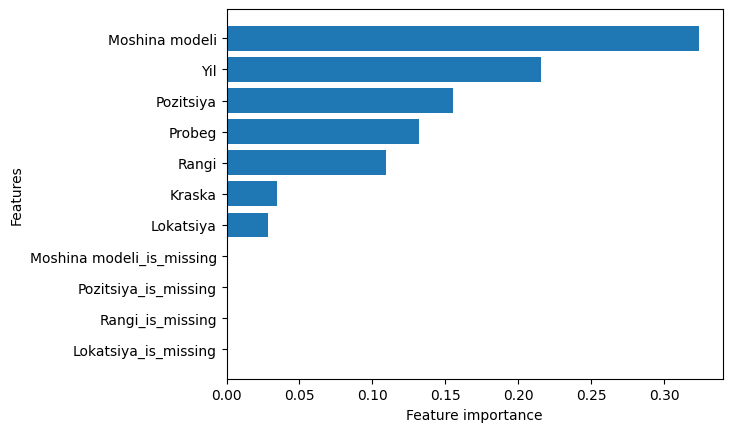

In [ ]:
plot_features(X_train.columns, loaded_model.feature_importances_)

In [ ]:
# prompt: I want to predict some car prices using my mode, for this I want to create some app, that will get values as a promt and return predicted value

import joblib
import pandas as pd
import numpy as np

# Load the trained model
loaded_model = joblib.load('/content/drive/MyDrive/ideal_model_fin.joblib')

def predict_car_price():
    """
    Collects car features from the user, predicts the price using the loaded model, and returns the result.
    """

    # Create an empty dictionary to store the input features.
    # Make sure the order and names match your training data
    input_data = {}

    # Updated features to match those expected by the model:
    features = ['Moshina modeli','Pozitsiya', 'Kraska', 'Rangi', 'Yil', 'Probeg', 'Location', 'Moshina modeli_is_missing',
                'Pozitsiya_is_missing', 'Rangi_is_missing', 'Location_is_missing']

    for feature in features:
        while True:
            try:
                if feature.endswith('_is_missing'):
                    value = input(f"Was {feature[:-11]} missing in the original data? (yes/no): ").lower()
                    if value == "yes":
                        input_data[feature] = 1
                    elif value == "no":
                        input_data[feature] = 0
                    else:
                        raise ValueError("Please enter 'yes' or 'no'.")
                else:
                    value = int(input(f"Enter {feature}: ")) # Make sure to convert to correct data type if needed
                    input_data[feature] = value
                break  # Exit the loop if the input is valid
            except ValueError:
                print(f"Invalid input for {feature}. Please enter an integer.")

    # Convert the input data to a DataFrame
    input_df = pd.DataFrame([input_data])

    # Make the prediction
    predicted_price = loaded_model.predict(input_df)[0]

    return predicted_price


if __name__ == "__main__":
    price = predict_car_price()
    print(f"Predicted car price: {price}")

Enter Moshina modeli: 653
Enter Pozitsiya: 398
Enter Kraska: 2
Enter Rangi: 302
Enter Yil: 2019
Enter Probeg: 126000
Enter Location: 3
Was Moshina modeli missing in the original data? (yes/no): no
Was Pozitsiya missing in the original data? (yes/no): no
Was Rangi missing in the original data? (yes/no): no
Was Location missing in the original data? (yes/no): no
Predicted car price: 14848.333333333336


In [ ]:
 0   Moshina modeli             19421 non-null  int16
 1   Pozitsiya                  19421 non-null  int16
 2   Kraska                     19421 non-null  int64
 3   Rangi                      19421 non-null  int16
 4   Yil                        19421 non-null  int64
 5   Probeg                     19421 non-null  float64
 6   Narxi                      19421 non-null  int64
 7   Lokatsiya                  19421 non-null  int16
 8   Moshina modeli_is_missing  19421 non-null  bool
 9   Pozitsiya_is_missing       19421 non-null  bool
 10  Rangi_is_missing           19421 non-null  bool
 11  Lokatsiya_is_missing       19421 non-null  bool